In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from lightgbm import LGBMClassifier
from sklearn.cluster import KMeans
sns.set_theme()

In [2]:
df = pd.read_csv(
    r'C:\Fause\Programas\EngSoft\repos\ML-Transportes\PBIC\acidentes_pbic_somas.csv',
    encoding='utf-8',
    parse_dates=['data_inversa'],
    dayfirst=True,
    low_memory=False
)

print("Shape inicial:", df.shape)



Shape inicial: (1678326, 53)


In [3]:
df["severity_index"] = (
    5 * df["Sum_Mortos"] +
    3 * df["Sum_Feridos_Graves"] +
    1 * df["Sum_Feridos_Leves"]
)

# --- Target transformada para ML ---
df["severity_index_log"] = np.log1p(df["severity_index"])


df["km"] = (
    df["km"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df["km"] = pd.to_numeric(df["km"], errors="coerce")

df = df.dropna(subset=["km"])



In [4]:
df["km_bin"] = (df["km"] // 5) * 5   # segmentos de 5 km

df_segmento = df.groupby(["br", "uf", "km_bin"]).agg({
    "severity_index": "mean",
    "id": "count"
}).reset_index()

df_segmento.rename(columns={"id": "n_acidentes"}, inplace=True)

df_segmento["score_risco"] = ( df_segmento["severity_index"] * np.log1p(df_segmento["n_acidentes"]))

df_segmento = df_segmento.sort_values("score_risco", ascending=False)

In [5]:
df["severity_log"] = np.log1p(df["severity_index"])

df = df[df["severity_index"] >= 0]

df["idade_veiculo"] = 2025 - df["ano_fabricacao_veiculo"]

df["latitude"] = (
    df["latitude"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df["longitude"] = (
    df["longitude"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")

In [6]:
features = [
    "uf",
    "br",
    "km_bin",
    "hora",
    #'horario',
    "mes",
    "dia_semana",
    'dia_mes',
    "tipo_acidente",
    "fase_dia",
    "condicao_metereologica",
    "tipo_pista",
    "tracado_via",
    "uso_solo", #*
    "tipo_veiculo",
    #"idade",
    #'sexo',
    "idade_veiculo",
    'latitude', 
    'longitude',
    'regional', 
    'Fabricante',
    #'Modelo'
]

df = df.dropna(subset=["severity_log"])

for col in features:
    
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
        
    else:
        df[col] = df[col].fillna("Desconhecido")


categoricas = df[features].select_dtypes(include="object").columns

for col in categoricas:
    df[col] = df[col].astype("category")

X = df[features]
y = df["severity_log"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

C:\Users\fause\AppData\Local\Temp\ipykernel_2320\242499999.py:38: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df[features].select_dtypes(include="object").columns


In [7]:
import lightgbm as lgb

# modelo = lgb.LGBMRegressor(
#     n_estimators=400,
#     learning_rate=0.05,
#     num_leaves=64,
#     random_state=42,
#     n_jobs=-1,
#     force_col_wise=True,
#     max_bin=512

# )

modelo = lgb.LGBMRegressor(
    n_estimators=800,          # mais árvores
    learning_rate=0.03,        # aprendizado mais suave
    num_leaves=128,            # mais capacidade
    max_depth=-1,              # sem limite explícito
    min_child_samples=40,      # evita overfitting
    subsample=0.8,             # bagging
    colsample_bytree=0.8,      # feature sampling
    reg_alpha=0.5,             # regularização L1
    reg_lambda=0.5,            # regularização L2
    random_state=42,
    n_jobs=-1,
    force_col_wise=True,
    max_bin=512
)

modelo.fit(X_train, y_train)

[LightGBM] [Info] Total Bins 2144
[LightGBM] [Info] Number of data points in the train set: 1140468, number of used features: 19
[LightGBM] [Info] Start training from score 0.634509


,boosting_type,'gbdt'
,num_leaves,128
,max_depth,-1
,learning_rate,0.03
,n_estimators,800
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,40


In [8]:
# import shap
# import numpy as np

# # pegar amostra aleatória pequena
# X_sample = X_test.sample(5000, random_state=42)

# explainer = shap.TreeExplainer(modelo)
# shap_values = explainer.shap_values(X_sample)

# shap.summary_plot(shap_values, X_sample)

In [9]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

pred = modelo.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.494805043455636
R2: 0.45883044084943636


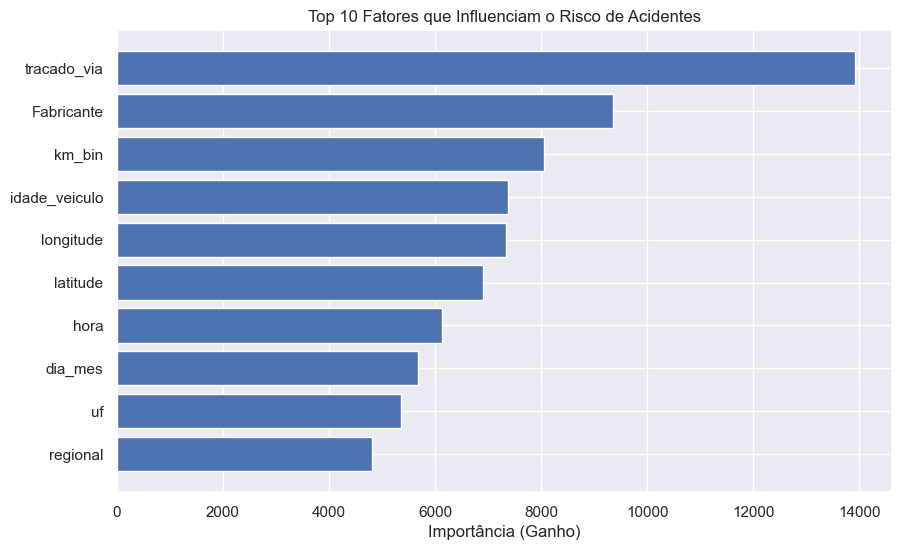

In [10]:
import matplotlib.pyplot as plt

# Pegando a importância das colunas
importancias = pd.DataFrame({
    'feature': X_train.columns,
    'importancia': modelo.feature_importances_
}).sort_values('importancia', ascending=False)

# Plotando
plt.figure(figsize=(10, 6))
plt.barh(importancias['feature'][:10], importancias['importancia'][:10])
plt.xlabel("Importância (Ganho)")
plt.title("Top 10 Fatores que Influenciam o Risco de Acidentes")
plt.gca().invert_yaxis()
plt.show()

In [11]:
importances = pd.DataFrame({
    "feature": X.columns,
    "importance": modelo.feature_importances_
}).sort_values("importance", ascending=False)

print(importances)

                   feature  importance
11             tracado_via       13912
18              Fabricante        9355
2                   km_bin        8062
14           idade_veiculo        7368
16               longitude        7342
15                latitude        6896
3                     hora        6128
6                  dia_mes        5675
0                       uf        5365
17                regional        4821
5               dia_semana        4718
7            tipo_acidente        4341
13            tipo_veiculo        4145
4                      mes        3976
1                       br        3542
9   condicao_metereologica        2781
8                 fase_dia        1159
10              tipo_pista        1064
12                uso_solo         950


In [12]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = cross_val_score(modelo, X, y, cv=kf, scoring='r2')

print("R2 por fold:", r2_scores)
print("R2 médio:", np.mean(r2_scores))
print("Desvio padrão:", np.std(r2_scores))

rmse_scores = -cross_val_score(modelo, X, y, cv=kf,
                                scoring='neg_root_mean_squared_error')

print("RMSE médio:", np.mean(rmse_scores))

[LightGBM] [Info] Total Bins 2144
[LightGBM] [Info] Number of data points in the train set: 1140468, number of used features: 19
[LightGBM] [Info] Start training from score 0.634509
[LightGBM] [Info] Total Bins 2148
[LightGBM] [Info] Number of data points in the train set: 1140468, number of used features: 19
[LightGBM] [Info] Start training from score 0.634521
[LightGBM] [Info] Total Bins 2154
[LightGBM] [Info] Number of data points in the train set: 1140468, number of used features: 19
[LightGBM] [Info] Start training from score 0.634057
[LightGBM] [Info] Total Bins 2150
[LightGBM] [Info] Number of data points in the train set: 1140468, number of used features: 19
[LightGBM] [Info] Start training from score 0.634302
[LightGBM] [Info] Total Bins 2158
[LightGBM] [Info] Number of data points in the train set: 1140468, number of used features: 19
[LightGBM] [Info] Start training from score 0.634138
R2 por fold: [0.45873925 0.45694549 0.45631794 0.45914477 0.45741272]
R2 médio: 0.45771203

In [13]:
# import shap

# X_sample = X_test.sample(5000, random_state=42)

# explainer = shap.TreeExplainer(modelo)
# shap_values = explainer.shap_values(X_test)

# shap.summary_plot(shap_values, X_test)

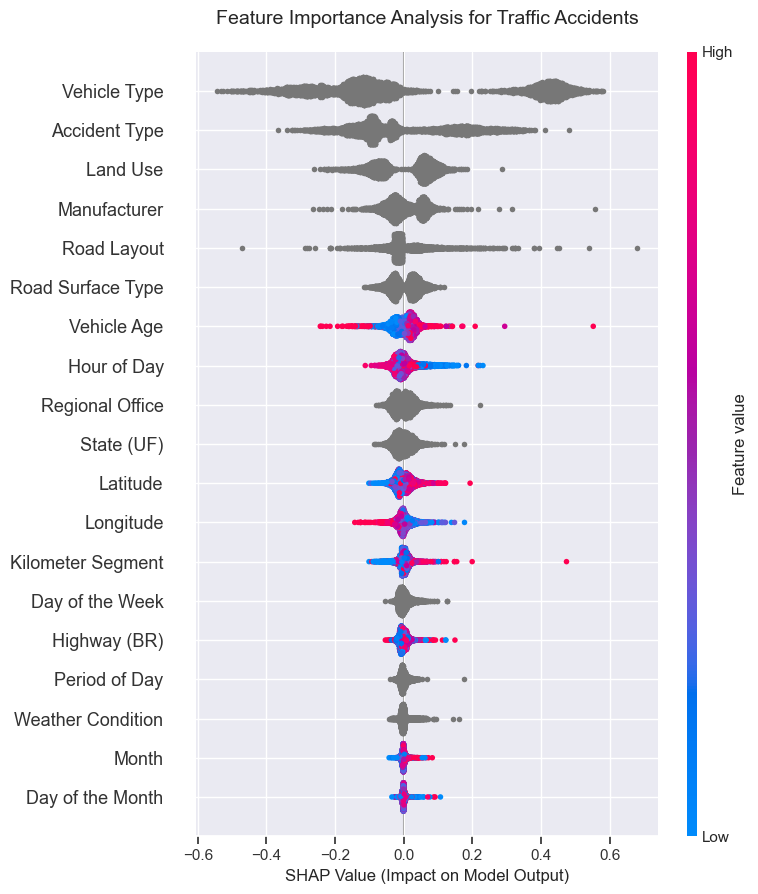

In [14]:
import shap
import matplotlib.pyplot as plt

# 1. Dicionário de Tradução (Baseado nas suas features)
translation_dict = {
    "uf": "State (UF)",
    "br": "Highway (BR)",
    "km_bin": "Kilometer Segment",
    "hora": "Hour of Day",
    "mes": "Month",
    "dia_semana": "Day of the Week",
    "dia_mes": "Day of the Month",
    "tipo_acidente": "Accident Type",
    "fase_dia": "Period of Day",
    "condicao_metereologica": "Weather Condition",
    "tipo_pista": "Road Surface Type",
    "tracado_via": "Road Layout",
    "uso_solo": "Land Use",
    "tipo_veiculo": "Vehicle Type",
    "idade_veiculo": "Vehicle Age",
    "latitude": "Latitude", 
    "longitude": "Longitude",
    "regional": "Regional Office", 
    "Fabricante": "Manufacturer"
}

# 2. Preparação dos dados (Amostra e Tradução)
# É importante traduzir o X_test antes de passar pelo explainer
X_test_en = X_test.rename(columns=translation_dict)
X_sample = X_test_en.sample(5000, random_state=42)

# 3. Execução do Explainer
explainer = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X_sample)

# 4. Bloco de Plotagem
plt.figure(figsize=(10, 8)) # Ajuste o tamanho para o layout do artigo

# Se for classificação multiclasse, escolha a classe (ex: [1] para 'Grave')
# Se for regressão ou binário, use apenas: shap.summary_plot(shap_values, X_sample, show=False)
shap.summary_plot(shap_values, X_sample, show=False)

# Tradução dos labels dos eixos
plt.xlabel("SHAP Value (Impact on Model Output)", fontsize=12)
plt.title("Feature Importance Analysis for Traffic Accidents", fontsize=14, pad=20)

# Salvar com alta resolução para o artigo
plt.tight_layout()
plt.savefig("shap_summary_english.png", dpi=300, bbox_inches='tight')
plt.show()

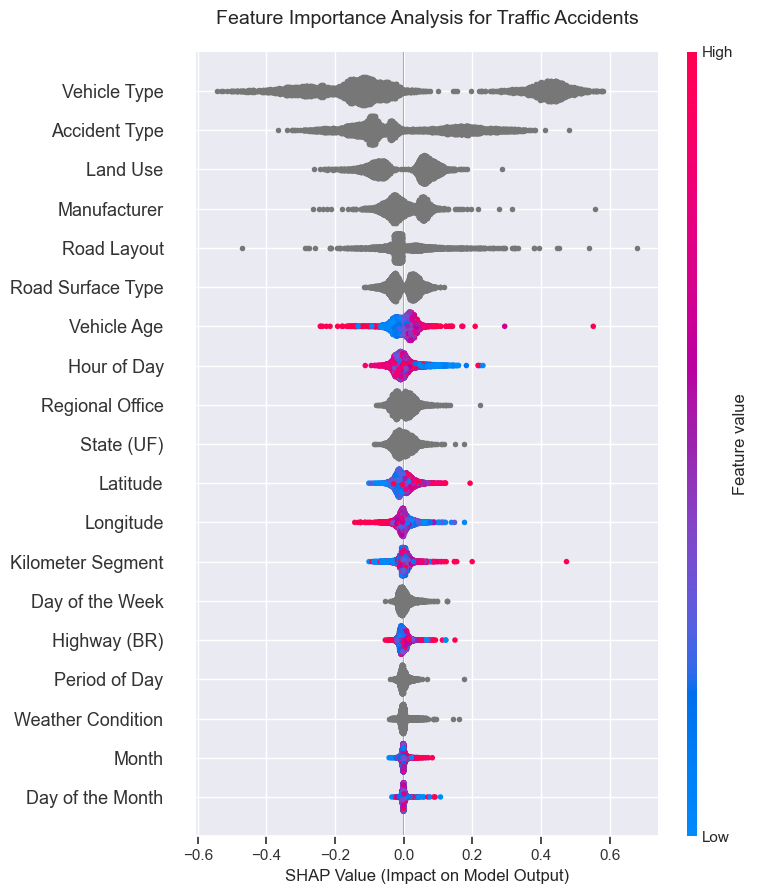

In [15]:
import shap
import matplotlib.pyplot as plt

# 1. Dicionário de Tradução (Baseado nas suas features)
translation_dict = {
    "uf": "State (UF)",
    "br": "Highway (BR)",
    "km_bin": "Kilometer Segment",
    "hora": "Hour of Day",
    "mes": "Month",
    "dia_semana": "Day of the Week",
    "dia_mes": "Day of the Month",
    "tipo_acidente": "Accident Type",
    "fase_dia": "Period of Day",
    "condicao_metereologica": "Weather Condition",
    "tipo_pista": "Road Surface Type",
    "tracado_via": "Road Layout",
    "uso_solo": "Land Use",
    "tipo_veiculo": "Vehicle Type",
    "idade_veiculo": "Vehicle Age",
    "latitude": "Latitude", 
    "longitude": "Longitude",
    "regional": "Regional Office", 
    "Fabricante": "Manufacturer"
}

# 2. Preparação dos dados (Amostra e Tradução)
# É importante traduzir o X_test antes de passar pelo explainer
X_test_en = X_test.rename(columns=translation_dict)
X_sample = X_test_en.sample(5000, random_state=42)

# 3. Execução do Explainer
explainer = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X_sample)

# 4. Bloco de Plotagem
plt.figure(figsize=(10, 8)) # Ajuste o tamanho para o layout do artigo

# Se for classificação multiclasse, escolha a classe (ex: [1] para 'Grave')
# Se for regressão ou binário, use apenas: shap.summary_plot(shap_values, X_sample, show=False)
shap.summary_plot(shap_values, X_sample, show=False)

# Tradução dos labels dos eixos
plt.xlabel("SHAP Value (Impact on Model Output)", fontsize=12)
plt.title("Feature Importance Analysis for Traffic Accidents", fontsize=14, pad=20)

# Salvar com alta resolução para o artigo
plt.tight_layout()
plt.savefig("shap_summary_english.png", dpi=300, bbox_inches='tight')
plt.show()

In [16]:
# print("\nSeveridade média por fase do dia:")
# print(df.groupby("fase_dia")["severity_index"].mean())

# print("\nSeveridade média por tipo de pista:")
# print(df.groupby("tipo_pista")["severity_index"].mean())

# print("\nSeveridade média por condição meteorológica:")
# print(df.groupby("condicao_metereologica")["severity_index"].mean())

# print("\nTop 10 tipos de acidente mais severos:")
# print(
#     df.groupby("tipo_acidente")["severity_index"]
#     .mean()
#     .sort_values(ascending=False)
#     .head(10)
# )

In [17]:
print("Linhas atuais:", len(df))

Linhas atuais: 1425585


In [18]:
# =============================
# 📊 Totais gerais
# =============================

total_acidentes = len(df)
total_segmentos = len(df_segmento)

print("Total de acidentes no dataset:", total_acidentes)
print("Total de segmentos analisados:", total_segmentos)

Total de acidentes no dataset: 1425585
Total de segmentos analisados: 12157


In [19]:
print("Shape inicial:", df.shape)

Shape inicial: (1425585, 58)


In [20]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

def rodar_pdp(
    modelo,
    X,
    nome_modelo="Modelo",
    sample_size=None
):
    # se quiser performance
    if sample_size:
        X_plot = X.sample(sample_size, random_state=42)
    else:
        X_plot = X

    features = [
        ("hora", None),
        ("mes", ["mes"] if X["mes"].dtype == "object" else None),
        ("dia_semana", ["dia_semana"]),
        ("idade_veiculo", None),
        ("tipo_pista", ["tipo_pista"]),
        ("fase_dia", ["fase_dia"]),
        ("condicao_metereologica", ["condicao_metereologica"]),
    ]

    for feature, cat in features:
        PartialDependenceDisplay.from_estimator(
            modelo,
            X_plot,
            [feature],
            categorical_features=cat,
            grid_resolution=50 if feature == "idade_veiculo" else 100,
            kind="average"
        )

        plt.title(f"{nome_modelo} - Impacto de {feature}")
        
        if feature == "idade_veiculo":
            plt.xlim(0, 35)

        plt.show()

    # 🔥 análise por clima (interação)
    top_climas = X["condicao_metereologica"].value_counts().head(4).index

    for clima in top_climas:
        subset = X[X["condicao_metereologica"] == clima]

        if sample_size:
            subset = subset.sample(min(sample_size, len(subset)), random_state=42)

        PartialDependenceDisplay.from_estimator(
            modelo,
            subset,
            ["hora"]
        )

        plt.title(f"{nome_modelo} - Risco por hora ({clima})")
        plt.show()

c:\Fause\Programas\EngSoft\repos\ML-Transportes\venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


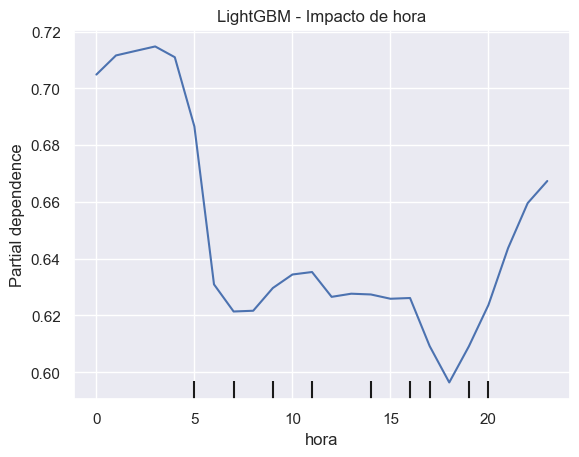

c:\Fause\Programas\EngSoft\repos\ML-Transportes\venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 4 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


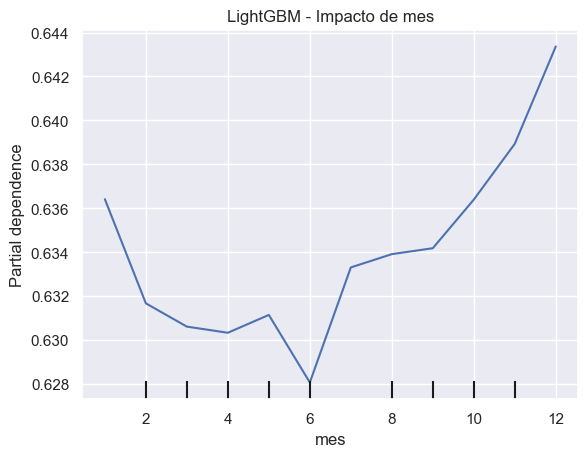

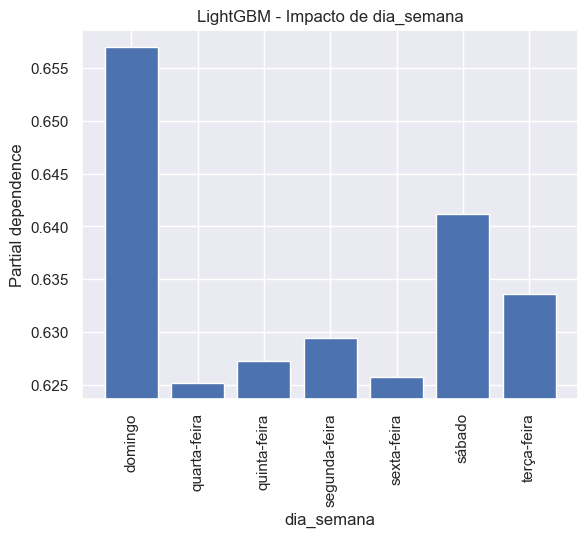

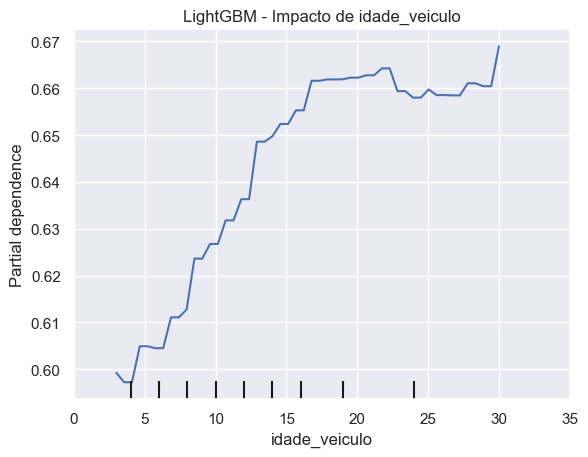

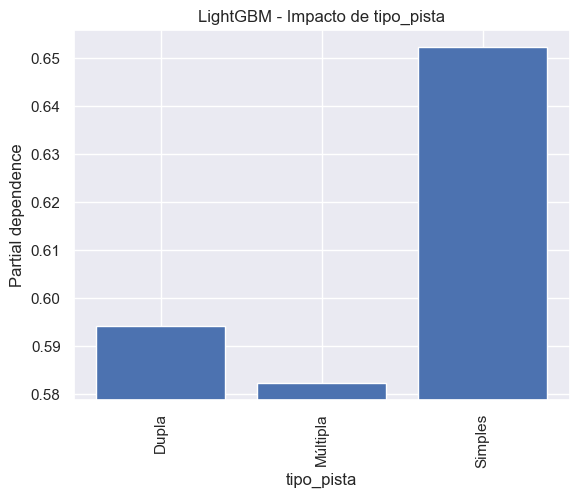

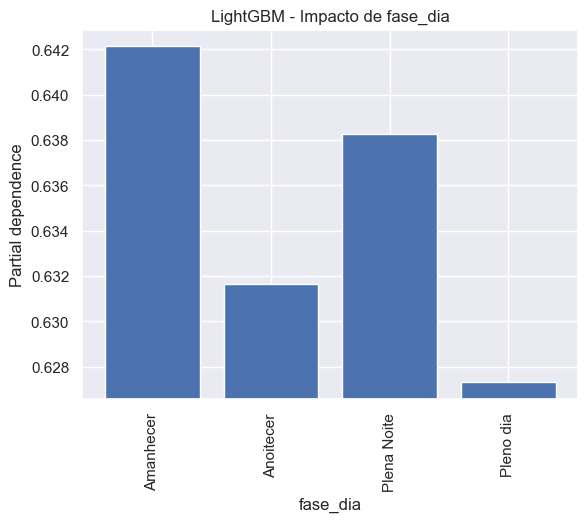

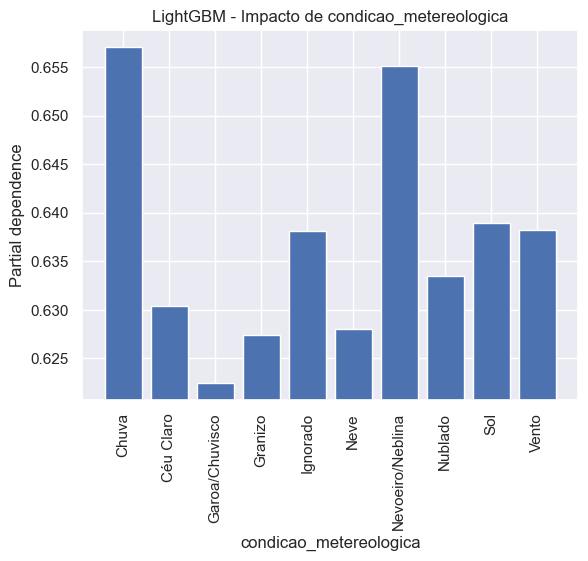

c:\Fause\Programas\EngSoft\repos\ML-Transportes\venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


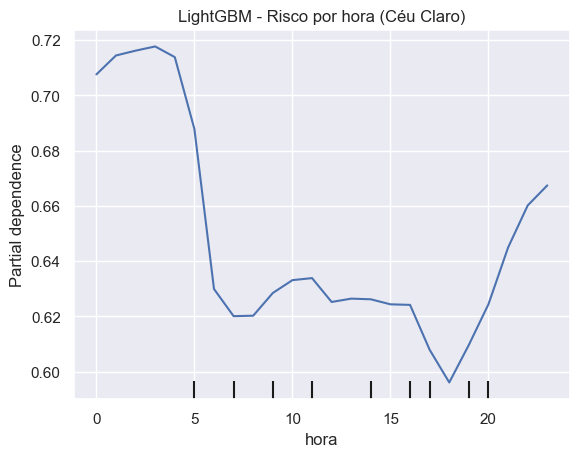

c:\Fause\Programas\EngSoft\repos\ML-Transportes\venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


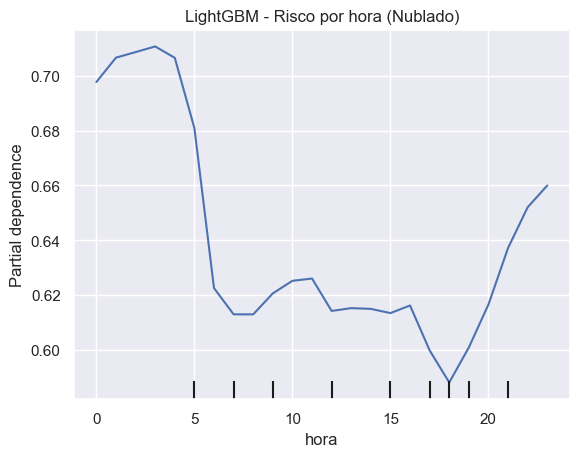

c:\Fause\Programas\EngSoft\repos\ML-Transportes\venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


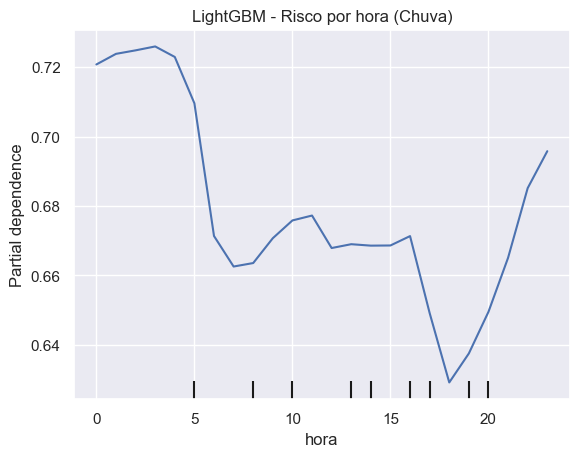

c:\Fause\Programas\EngSoft\repos\ML-Transportes\venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


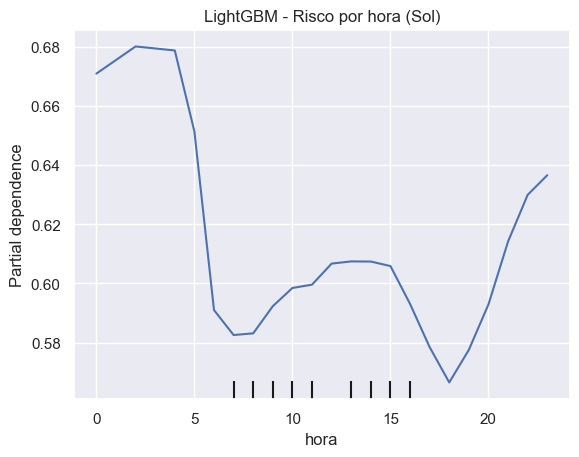

In [21]:
rodar_pdp(modelo, X_test, nome_modelo="LightGBM")

In [22]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

def rodar_pdp_categoricas(
    modelo,
    X,
    nome_modelo="Modelo",
    sample_size=None
):
    # performance
    if sample_size:
        X_plot = X.sample(sample_size, random_state=42)
    else:
        X_plot = X

    # 🔥 novas features categóricas
    features = [
        ("tipo_veiculo", ["tipo_veiculo"]),
        ("tipo_acidente", ["tipo_acidente"]),
        ("uso_solo", ["uso_solo"]),
    ]

    for feature, cat in features:
        PartialDependenceDisplay.from_estimator(
            modelo,
            X_plot,
            [feature],
            categorical_features=cat,
            kind="average"
        )

        plt.title(f"{nome_modelo} - Impacto de {feature}")
        plt.ylabel("Probabilidade de Acidente Grave")

        plt.xticks(rotation=45)  # 🔥 melhora visual
        plt.tight_layout()

        plt.show()

    # 🔥 análise cruzada: tipo_veiculo vs hora
    top_veiculos = X["tipo_veiculo"].value_counts().head(4).index

    for veic in top_veiculos:
        subset = X[X["tipo_veiculo"] == veic]

        if sample_size:
            subset = subset.sample(min(sample_size, len(subset)), random_state=42)

        PartialDependenceDisplay.from_estimator(
            modelo,
            subset,
            ["hora"]
        )

        plt.title(f"{nome_modelo} - Risco por hora ({veic})")
        plt.ylabel("Probabilidade de Acidente Grave")

        plt.show()

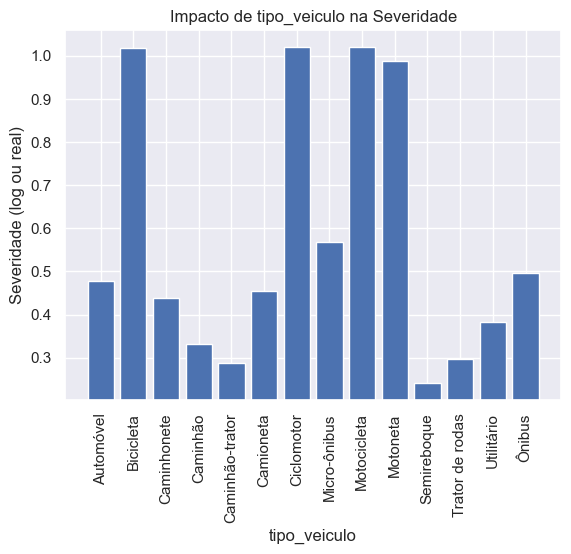

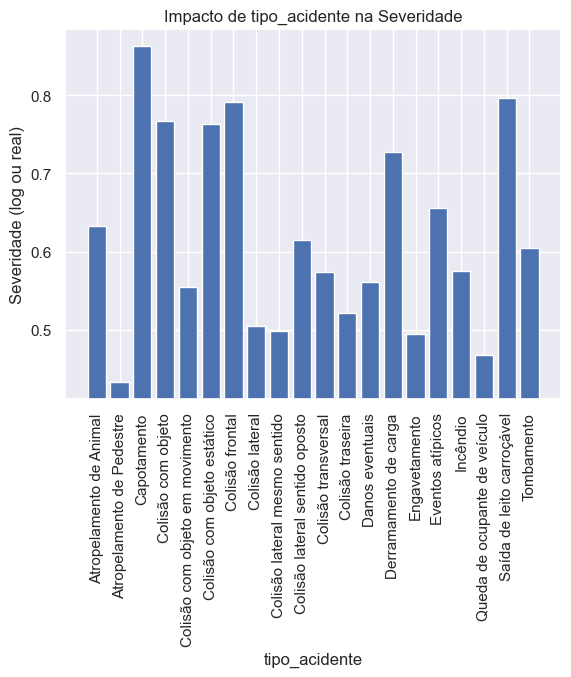

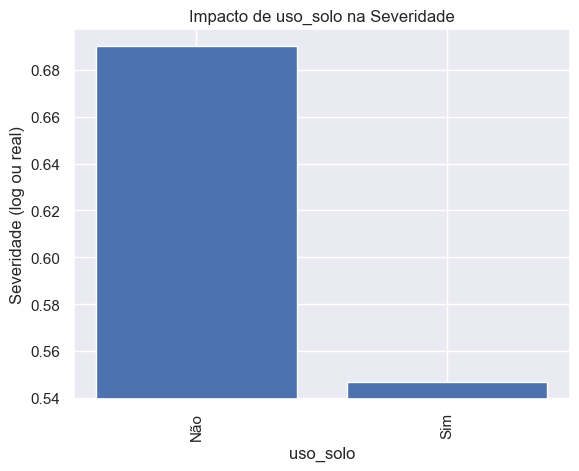

In [23]:
features_cat = ["tipo_veiculo", "tipo_acidente", "uso_solo"]

for feature in features_cat:
    
    PartialDependenceDisplay.from_estimator(
        modelo,
        X_test.sample(5000),
        [feature],
        categorical_features=[feature],
        kind="average"
    )

    plt.title(f"Impacto de {feature} na Severidade")
    plt.ylabel("Severidade (log ou real)")
    plt.show()

In [24]:
# import matplotlib.pyplot as plt
# import shap
# from sklearn.inspection import PartialDependenceDisplay

# # ==========================================================
# # 1. DICIONÁRIOS DE TRADUÇÃO (TECHNICAL TERMS)
# # ==========================================================

# map_features = {
#     "uf": "State (UF)", "br": "Highway (BR)", "km_bin": "Kilometer Segment",
#     "hora": "Hour of Day", "mes": "Month", "dia_semana": "Day of the Week",
#     "dia_mes": "Day of the Month", "tipo_acidente": "Accident Type",
#     "fase_dia": "Period of Day", "condicao_metereologica": "Weather Condition",
#     "tipo_pista": "Road Surface Type", "tracado_via": "Road Layout",
#     "uso_solo": "Land Use", "tipo_veiculo": "Vehicle Type",
#     "idade_veiculo": "Vehicle Age", "latitude": "Latitude", 
#     "longitude": "Longitude", "regional": "Regional Office", 
#     "Fabricante": "Manufacturer"
# }

# map_veiculo = {
#     'Automóvel': 'Car', 'Outros': 'Others', 'Caminhonete': 'Pickup Truck',
#     'Motocicleta': 'Motorcycle', 'Caminhão-trator': 'Tractor Truck',
#     'Motoneta': 'Scooter', 'Caminhão': 'Truck', 'Camioneta': 'SUV/Van',
#     'Micro-ônibus': 'Minibus', 'Bicicleta': 'Bicycle', 'Ônibus': 'Bus',
#     'Utilitário': 'Utility Vehicle', 'Ciclomotor': 'Moped', 'Semireboque': 'Semi-trailer',
#     'Trator de rodas': 'Wheel Tractor', 'Motor-casa': 'Motorhome', 'Reboque': 'Trailer',
#     'Carroça-charrete': 'Animal-drawn Cart', 'Chassi-plataforma': 'Chassis-platform',
#     'Trem-bonde': 'Train/Tram', 'Triciclo': 'Tricycle', 'Carro de mão': 'Handcart',
#     'Trator misto': 'Mixed Tractor', 'Quadriciclo': 'Quadricycle', 'Trator de esteira': 'Crawler Tractor'
# }

# map_acidente = {
#     'Saída de leito carroçável': 'Run-off-road', 'Atropelamento de Animal': 'Animal Collision',
#     'Atropelamento de Pedestre': 'Pedestrian Collision', 'Colisão lateral': 'Side Collision',
#     'Colisão com objeto estático': 'Fixed Object Collision', 'Tombamento': 'Overturning',
#     'Capotamento': 'Rollover', 'Colisão transversal': 'Cross-traffic Collision',
#     'Colisão frontal': 'Head-on Collision', 'Queda de ocupante de veículo': 'Fall from Vehicle',
#     'Incêndio': 'Fire', 'Colisão traseira': 'Rear-end Collision',
#     'Derramamento de carga': 'Cargo Spillage', 'Engavetamento': 'Pile-up',
#     'Colisão com objeto em movimento': 'Moving Object Collision', 'Danos eventuais': 'Accidental Damage',
#     'Colisão com objeto': 'Object Collision', 'Colisão lateral mesmo sentido': 'Same-direction Side',
#     'Colisão lateral sentido oposto': 'Opposite-direction Side', 'Eventos atípicos': 'Atypical Events',
#     'Sinistro pessoal de trânsito': 'Personal Incident'
# }

# map_uso_solo = {'Sim': 'yes', 'Não': 'no'}

# # ==========================================================
# # 2. PREPARAÇÃO DOS DADOS (TRANSLATION & SAMPLING)
# # ==========================================================

# X_test_en = X_test.copy()
# X_test_en['tipo_veiculo'] = X_test_en['tipo_veiculo'].map(map_veiculo)
# X_test_en['tipo_acidente'] = X_test_en['tipo_acidente'].map(map_acidente)
# X_test_en['uso_solo'] = X_test_en['uso_solo'].map(map_uso_solo)
# X_test_en = X_test_en.rename(columns=map_features)

# X_sample_en = X_test_en.sample(5000, random_state=42)

# # ==========================================================
# # 3. BLOCO SHAP SUMMARY PLOT
# # ==========================================================

# explainer = shap.TreeExplainer(modelo)
# shap_values = explainer.shap_values(X_sample_en)

# plt.figure(figsize=(10, 8))
# # Se for multiclasse, use shap_values[1] (ou a classe alvo)
# shap.summary_plot(shap_values, X_sample_en, show=False)
# plt.xlabel("SHAP Value (Impact on Severity Index)", fontsize=12)
# plt.title("Feature Importance - SHAP Analysis", fontsize=14, pad=20)
# plt.savefig("shap_summary_en.png", dpi=300, bbox_inches='tight')
# plt.show()

# # ==========================================================
# # 4. BLOCO PARTIAL DEPENDENCE PLOTS (PDP)
# # ==========================================================

# features_cat_en = ["Vehicle Type", "Accident Type", "Land Use"]

# for feature in features_cat_en:
#     fig, ax = plt.subplots(figsize=(12, 7))
    
#     PartialDependenceDisplay.from_estimator(
#         modelo,
#         X_sample_en,
#         [feature],
#         categorical_features=[feature],
#         kind="average",
#         ax=ax
#     )

#     plt.title(f"Partial Dependence of {feature} on Severity", fontsize=14)
#     plt.ylabel("Partial Dependence (Model Output)", fontsize=12)
#     plt.xlabel(feature, fontsize=12)
#     plt.xticks(rotation=45, ha='right')
    
#     plt.tight_layout()
#     plt.savefig(f"pdp_{feature.replace(' ', '_').lower()}.png", dpi=300)
#     plt.show()

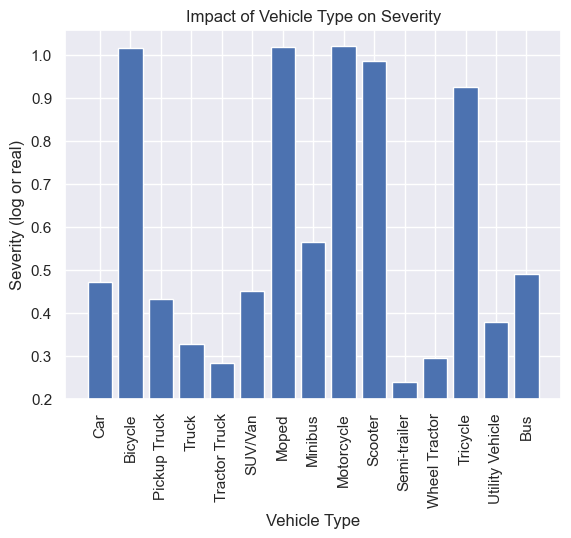

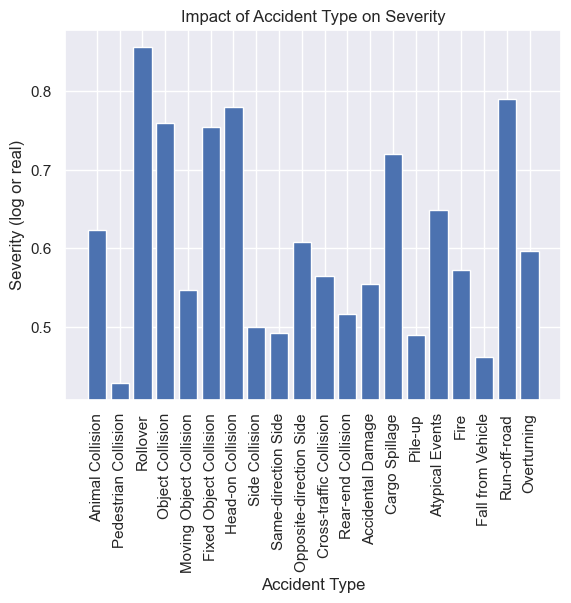

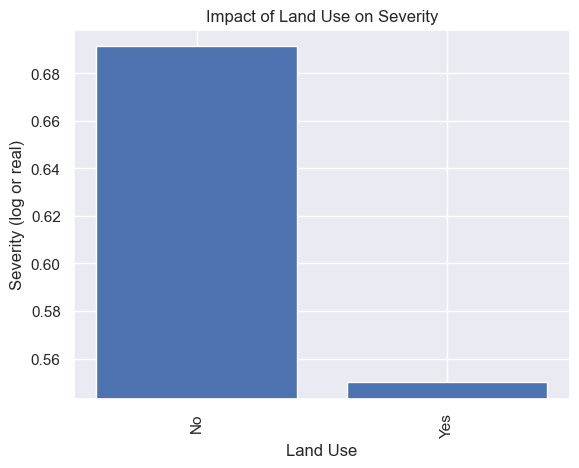

In [25]:
import matplotlib.pyplot as plt

# 1. Seus mapeamentos originais
map_veiculo = {
    'Automóvel': 'Car', 'Outros': 'Others', 'Caminhonete': 'Pickup Truck',
    'Motocicleta': 'Motorcycle', 'Caminhão-trator': 'Tractor Truck',
    'Motoneta': 'Scooter', 'Caminhão': 'Truck', 'Camioneta': 'SUV/Van',
    'Micro-ônibus': 'Minibus', 'Bicicleta': 'Bicycle', 'Ônibus': 'Bus',
    'Utilitário': 'Utility Vehicle', 'Ciclomotor': 'Moped', 'Semireboque': 'Semi-trailer',
    'Trator de rodas': 'Wheel Tractor', 'Motor-casa': 'Motorhome', 'Reboque': 'Trailer',
    'Carroça-charrete': 'Animal-drawn Cart', 'Chassi-plataforma': 'Chassis-platform',
    'Trem-bonde': 'Train/Tram', 'Triciclo': 'Tricycle', 'Carro de mão': 'Handcart',
    'Trator misto': 'Mixed Tractor', 'Quadriciclo': 'Quadricycle', 'Trator de esteira': 'Crawler Tractor'
}

map_acidente = {
    'Saída de leito carroçável': 'Run-off-road', 'Atropelamento de Animal': 'Animal Collision',
    'Atropelamento de Pedestre': 'Pedestrian Collision', 'Colisão lateral': 'Side Collision',
    'Colisão com objeto estático': 'Fixed Object Collision', 'Tombamento': 'Overturning',
    'Capotamento': 'Rollover', 'Colisão transversal': 'Cross-traffic Collision',
    'Colisão frontal': 'Head-on Collision', 'Queda de ocupante de veículo': 'Fall from Vehicle',
    'Incêndio': 'Fire', 'Colisão traseira': 'Rear-end Collision',
    'Derramamento de carga': 'Cargo Spillage', 'Engavetamento': 'Pile-up',
    'Colisão com objeto em movimento': 'Moving Object Collision', 'Danos eventuais': 'Accidental Damage',
    'Colisão com objeto': 'Object Collision', 'Colisão lateral mesmo sentido': 'Same-direction Side',
    'Colisão lateral sentido oposto': 'Opposite-direction Side', 'Eventos atípicos': 'Atypical Events',
    'Sinistro pessoal de trânsito': 'Personal Incident'
}

map_uso_solo = {'Sim': 'Yes', 'Não': 'No'} # Deixei o Y e N maiúsculos para o gráfico ficar mais formal

# 2. Mapeamento dos nomes das colunas (features)
feature_translations = {
    "tipo_veiculo": "Vehicle Type",
    "tipo_acidente": "Accident Type",
    "uso_solo": "Land Use"
}

# 3. Criamos um super dicionário relacionando a coluna ao seu respectivo mapeamento
traducoes_por_coluna = {
    "tipo_veiculo": map_veiculo,
    "tipo_acidente": map_acidente,
    "uso_solo": map_uso_solo
}

features_cat = ["tipo_veiculo", "tipo_acidente", "uso_solo"]

for feature in features_cat:
    
    # Gera o gráfico original baseado no modelo em PT
    display = PartialDependenceDisplay.from_estimator(
        modelo,
        X_test.sample(5000),
        [feature],
        categorical_features=[feature],
        kind="average"
    )

    ax = plt.gca()
    
    # Traduz o nome da Feature no eixo X
    feature_en = feature_translations.get(feature, feature)
    ax.set_xlabel(feature_en)
    
    # Identifica qual dicionário de categorias usar para a feature atual
    dicionario_atual = traducoes_por_coluna.get(feature, {})
    
    # Captura os rótulos em PT do gráfico e traduz usando o dicionário específico
    ticks = ax.get_xticks()
    old_labels = [label.get_text() for label in ax.get_xticklabels()]
    new_labels = [dicionario_atual.get(label, label) for label in old_labels]
    
    # Aplica as alterações de texto no eixo X
    ax.set_xticks(ticks)
    ax.set_xticklabels(new_labels)

    # Configura os títulos finais em Inglês
    plt.title(f"Impact of {feature_en} on Severity")
    plt.ylabel("Severity (log or real)")
    
    plt.show()